# GPT-2 — Permutation Test (1,000 iterations)

**Phase 3:** Permutation-validated causal profile for GPT-2.

**Hardware:** A100 80GB  
**Runtime:** ~25 minutes

**Run all cells top to bottom.**

**Expected outputs:**
- Layers 3, 6, 9: p <= 0.007 **
- Layer 11 (final): p = 0.512 n.s.
- Saved: `patching_permutation_test_gpt2.csv`


In [2]:
# Cell 1 — setup
!pip install -q numpy==1.26.4
!pip install -q transformer_lens
from datasets import load_dataset
import os, torch, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn.functional as F
from transformer_lens import HookedTransformer

OUTPUT_DIR = f'/content/drive/MyDrive/ID-UTH-repo/causal_patching'
os.makedirs(OUTPUT_DIR, exist_ok=True)
DEVICE = 'cuda'
GPT2_LAYERS = [3, 6, 9, 11]
N_PAIRS = 10
N_PERM = 1000
print(f'GPU: {torch.cuda.get_device_name(0)}')
print('Ready')

GPU: NVIDIA A100-SXM4-40GB
Ready


In [3]:
# Cell 2 — load BBQ
dataset = load_dataset('Elfsong/BBQ', split='race_ethnicity')
race_df = dataset.to_pandas()
race_ambig = race_df[race_df['context_condition'] == 'ambig'].reset_index(drop=True)

group_indices = {'Hispanic': [], 'Black': []}
for i, row in race_ambig.iterrows():
    context = row['context']
    if 'Hispanic' in context:
        group_indices['Hispanic'].append(i)
    elif 'Black' in context and 'African American' not in context:
        group_indices['Black'].append(i)

hispanic_rows = [race_ambig.iloc[i] for i in group_indices['Hispanic']]
black_rows    = [race_ambig.iloc[i] for i in group_indices['Black']]
print(f'Hispanic: {len(hispanic_rows)}, Black: {len(black_rows)}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/age-00000-of-00001.parquet:   0%|          | 0.00/160k [00:00<?, ?B/s]

data/disability_status-00000-of-00001.pa(…):   0%|          | 0.00/85.2k [00:00<?, ?B/s]

data/gender_identity-00000-of-00001.parq(…):   0%|          | 0.00/217k [00:00<?, ?B/s]

...

Generating race_x_ses split:   0%|          | 0/11160 [00:00<?, ? examples/s]

Generating religion split:   0%|          | 0/1200 [00:00<?, ? examples/s]

Generating ses split:   0%|          | 0/6864 [00:00<?, ? examples/s]

Generating sexual_orientation split:   0%|          | 0/864 [00:00<?, ? examples/s]

Hispanic: 164, Black: 236


In [4]:
# Cell 3 — helpers
def format_prompt(row):
    return (
        f"Context: {row['context']}\n"
        f"Question: {row['question']}\n"
        f"A) {row['ans0']}\n"
        f"B) {row['ans1']}\n"
        f"C) {row['ans2']}\n"
        f"Answer:"
    )

def get_label_token_pos(prompt, model, target_word):
    tokens = model.to_tokens(prompt)
    token_strings = [model.to_string(tokens[0][i]) for i in range(tokens.shape[1])]
    for i, tok in enumerate(token_strings):
        if target_word.strip() in tok.strip():
            return i, tokens
    return None, tokens

def get_output_logits(prompt, model):
    tokens = model.to_tokens(prompt)
    with torch.no_grad():
        logits = model(tokens)
    return logits[0, -1, :]

def kl_divergence(logits_a, logits_b):
    p_a = F.softmax(logits_a.float(), dim=-1)
    p_b = F.softmax(logits_b.float(), dim=-1)
    return F.kl_div(p_b.log(), p_a, reduction='sum').item()

def patch_and_measure(source_prompt, target_prompt,
                      source_label, target_label, layer, model):
    pos_s, src_tokens = get_label_token_pos(source_prompt, model, source_label)
    pos_t, tgt_tokens = get_label_token_pos(target_prompt, model, target_label)
    if pos_s is None or pos_t is None:
        return None
    with torch.no_grad():
        _, cache = model.run_with_cache(src_tokens)
    src_act = cache[f'blocks.{layer}.hook_resid_post'][0, pos_s, :].clone()
    orig_logits = get_output_logits(target_prompt, model)
    def hook(value, hook):
        value[0, pos_t, :] = src_act
        return value
    with torch.no_grad():
        patched_logits = model.run_with_hooks(
            tgt_tokens,
            fwd_hooks=[(f'blocks.{layer}.hook_resid_post', hook)]
        )[0, -1, :]
    return kl_divergence(orig_logits, patched_logits)

print('Helpers defined.')

Helpers defined.


In [5]:
# Cell 4 — load GPT-2
print('Loading GPT-2...')
model = HookedTransformer.from_pretrained('gpt2', device=DEVICE)
model.eval()
print('Loaded.')

Loading GPT-2...


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded pretrained model gpt2 into HookedTransformer
Loaded.


In [6]:
# Cell 5 — collect all pair activations upfront (saves time during permutation)
# Pre-extract: for each pair, store the KL we get from patching in each direction
# Then permutation test shuffles which prompt is source vs target

print('Extracting observed KL values for all pairs and layers...')
print('(Pre-extracting activations to speed up permutation test)')

# Store activations for all N_PAIRS prompts in both groups at all layers
all_acts = {'Hispanic': {l: [] for l in GPT2_LAYERS},
            'Black':    {l: [] for l in GPT2_LAYERS}}
all_logits = {'Hispanic': [], 'Black': []}

print('Extracting Hispanic activations...')
for i in range(N_PAIRS):
    row = hispanic_rows[i]
    prompt = format_prompt(row)
    tokens = model.to_tokens(prompt)
    pos, _ = get_label_token_pos(prompt, model, 'Hispanic')
    with torch.no_grad():
        logits = model(tokens)
        _, cache = model.run_with_cache(tokens)
    all_logits['Hispanic'].append(logits[0, -1, :].clone())
    for l in GPT2_LAYERS:
        if pos is not None:
            all_acts['Hispanic'][l].append(
                cache[f'blocks.{l}.hook_resid_post'][0, pos, :].clone())
        else:
            all_acts['Hispanic'][l].append(None)

print('Extracting Black activations...')
for i in range(N_PAIRS):
    row = black_rows[i]
    prompt = format_prompt(row)
    tokens = model.to_tokens(prompt)
    pos, _ = get_label_token_pos(prompt, model, 'Black')
    with torch.no_grad():
        logits = model(tokens)
        _, cache = model.run_with_cache(tokens)
    all_logits['Black'].append(logits[0, -1, :].clone())
    for l in GPT2_LAYERS:
        if pos is not None:
            all_acts['Black'][l].append(
                cache[f'blocks.{l}.hook_resid_post'][0, pos, :].clone())
        else:
            all_acts['Black'][l].append(None)

print('Extractions complete.')

Extracting observed KL values for all pairs and layers...
(Pre-extracting activations to speed up permutation test)
Extracting Hispanic activations...
Extracting Black activations...
Extractions complete.


In [7]:
# Cell 6 — compute observed cross-group KL for each layer and direction
def patch_with_stored(src_act, tgt_tokens_idx, orig_logits, layer, model):
    """Patch a stored activation into a stored target and measure KL."""
    if src_act is None:
        return None
    tgt_tokens = model.to_tokens(format_prompt(
        hispanic_rows[tgt_tokens_idx] if tgt_tokens_idx < N_PAIRS
        else black_rows[tgt_tokens_idx - N_PAIRS]))

    # Find target token pos
    tgt_group = 'Hispanic' if tgt_tokens_idx < N_PAIRS else 'Black'
    tgt_label = 'Hispanic' if tgt_group == 'Hispanic' else 'Black'
    pos_t, _ = get_label_token_pos(
        format_prompt(hispanic_rows[tgt_tokens_idx] if tgt_group == 'Hispanic'
                      else black_rows[tgt_tokens_idx - N_PAIRS]),
        model, tgt_label)
    if pos_t is None:
        return None

    def hook(value, hook):
        value[0, pos_t, :] = src_act
        return value

    with torch.no_grad():
        patched = model.run_with_hooks(
            tgt_tokens,
            fwd_hooks=[(f'blocks.{layer}.hook_resid_post', hook)]
        )[0, -1, :]

    return kl_divergence(orig_logits, patched)

print('Computing observed KL values...')
observed = {}
for layer in GPT2_LAYERS:
    kls_h2b = []
    kls_b2h = []
    for i in range(N_PAIRS):
        # H→B: patch Hispanic[i] activation into Black[i] prompt
        src = all_acts['Hispanic'][layer][i]
        orig = all_logits['Black'][i]
        row = black_rows[i]
        prompt = format_prompt(row)
        tokens = model.to_tokens(prompt)
        pos_t, _ = get_label_token_pos(prompt, model, 'Black')
        if src is not None and pos_t is not None:
            def hook_h2b(value, hook, s=src, p=pos_t):
                value[0, p, :] = s
                return value
            with torch.no_grad():
                patched = model.run_with_hooks(
                    tokens, fwd_hooks=[(f'blocks.{layer}.hook_resid_post', hook_h2b)]
                )[0, -1, :]
            kls_h2b.append(kl_divergence(orig, patched))

        # B→H: patch Black[i] activation into Hispanic[i] prompt
        src = all_acts['Black'][layer][i]
        orig = all_logits['Hispanic'][i]
        row = hispanic_rows[i]
        prompt = format_prompt(row)
        tokens = model.to_tokens(prompt)
        pos_t, _ = get_label_token_pos(prompt, model, 'Hispanic')
        if src is not None and pos_t is not None:
            def hook_b2h(value, hook, s=src, p=pos_t):
                value[0, p, :] = s
                return value
            with torch.no_grad():
                patched = model.run_with_hooks(
                    tokens, fwd_hooks=[(f'blocks.{layer}.hook_resid_post', hook_b2h)]
                )[0, -1, :]
            kls_b2h.append(kl_divergence(orig, patched))

    observed[layer] = {
        'H2B': kls_h2b, 'B2H': kls_b2h,
        'mean': np.mean(kls_h2b + kls_b2h),
        'mean_h2b': np.mean(kls_h2b),
        'mean_b2h': np.mean(kls_b2h)
    }
    print(f'Layer {layer}: H→B = {np.mean(kls_h2b):.4f}, B→H = {np.mean(kls_b2h):.4f}')

print('\nObserved values match paper Table 2: ✓' if abs(observed[3]['mean_h2b'] - 0.0173) < 0.003 else '\nNote: values may differ slightly from paper due to randomness')

Computing observed KL values...
Layer 3: H→B = 0.0173, B→H = 0.0181
Layer 6: H→B = 0.0171, B→H = 0.0194
Layer 9: H→B = 0.0088, B→H = 0.0097
Layer 11: H→B = -0.0000, B→H = -0.0000

Observed values match paper Table 2: ✓


In [8]:
# Cell 7 — permutation test
# Shuffle group labels 1000 times and recompute mean KL at each layer
# This tests whether observed cross-group KL exceeds what you'd get by chance

print(f'Running permutation test ({N_PERM} iterations)...')
print('This takes about 20-25 minutes on A100 for GPT-2.')
print()

# All 20 prompts pooled (10 Hispanic + 10 Black)
all_prompts = (
    [format_prompt(hispanic_rows[i]) for i in range(N_PAIRS)] +
    [format_prompt(black_rows[i]) for i in range(N_PAIRS)]
)
all_labels = ['Hispanic'] * N_PAIRS + ['Black'] * N_PAIRS

# Pre-extract all activations and logits for all 20 prompts
print('Pre-extracting activations for all 20 prompts...')
pool_acts  = {l: [] for l in GPT2_LAYERS}
pool_logits = []
pool_pos = []

for idx, (prompt, label) in enumerate(zip(all_prompts, all_labels)):
    tokens = model.to_tokens(prompt)
    pos, _ = get_label_token_pos(prompt, model, label)
    with torch.no_grad():
        logits = model(tokens)
        _, cache = model.run_with_cache(tokens)
    pool_logits.append(logits[0, -1, :].clone())
    pool_pos.append(pos)
    for l in GPT2_LAYERS:
        if pos is not None:
            pool_acts[l].append(cache[f'blocks.{l}.hook_resid_post'][0, pos, :].clone())
        else:
            pool_acts[l].append(None)

print('Extractions done. Starting permutation iterations...')

perm_means = {l: [] for l in GPT2_LAYERS}

for perm_idx in range(N_PERM):
    # Shuffle labels — randomly assign 10 to "group A" and 10 to "group B"
    shuffled = np.random.permutation(20)
    group_a = shuffled[:N_PAIRS]
    group_b = shuffled[N_PAIRS:]

    for layer in GPT2_LAYERS:
        kls = []
        for i in range(N_PAIRS):
            src_idx = group_a[i]
            tgt_idx = group_b[i]

            src_act = pool_acts[layer][src_idx]
            orig_logits = pool_logits[tgt_idx]
            tgt_pos = pool_pos[tgt_idx]

            if src_act is None or tgt_pos is None:
                continue

            tgt_tokens = model.to_tokens(all_prompts[tgt_idx])

            def hook_perm(value, hook, s=src_act, p=tgt_pos):
                value[0, p, :] = s
                return value

            with torch.no_grad():
                patched = model.run_with_hooks(
                    tgt_tokens,
                    fwd_hooks=[(f'blocks.{layer}.hook_resid_post', hook_perm)]
                )[0, -1, :]

            kls.append(kl_divergence(orig_logits, patched))

        if kls:
            perm_means[layer].append(np.mean(kls))

    if (perm_idx + 1) % 100 == 0:
        print(f'  {perm_idx + 1}/{N_PERM} iterations complete...')

print('\nPermutation test complete.')

Running permutation test (1000 iterations)...
This takes about 20-25 minutes on A100 for GPT-2.

Pre-extracting activations for all 20 prompts...
Extractions done. Starting permutation iterations...
  100/1000 iterations complete...
  200/1000 iterations complete...
  300/1000 iterations complete...
  400/1000 iterations complete...
  500/1000 iterations complete...
  600/1000 iterations complete...
  700/1000 iterations complete...
  800/1000 iterations complete...
  900/1000 iterations complete...
  1000/1000 iterations complete...

Permutation test complete.


PERMUTATION TEST RESULTS — GPT-2 Causal Patching

Layer 3:
  Observed mean KL:     0.0177
  Permuted 95th pct:    0.0146
  p-value (one-sided):  0.0030 **

Layer 6:
  Observed mean KL:     0.0182
  Permuted 95th pct:    0.0160
  p-value (one-sided):  0.0100 *

Layer 9:
  Observed mean KL:     0.0092
  Permuted 95th pct:    0.0078
  p-value (one-sided):  0.0050 **

Layer 11:
  Observed mean KL:     -0.0000
  Permuted 95th pct:    -0.0000
  p-value (one-sided):  0.4930 n.s.

Saved: /content/drive/MyDrive/ID-UTH-repo/causal_patching/patching_permutation_test_gpt2.csv
Saved: /content/drive/MyDrive/ID-UTH-repo/causal_patching/patching_permutation_test_gpt2.png


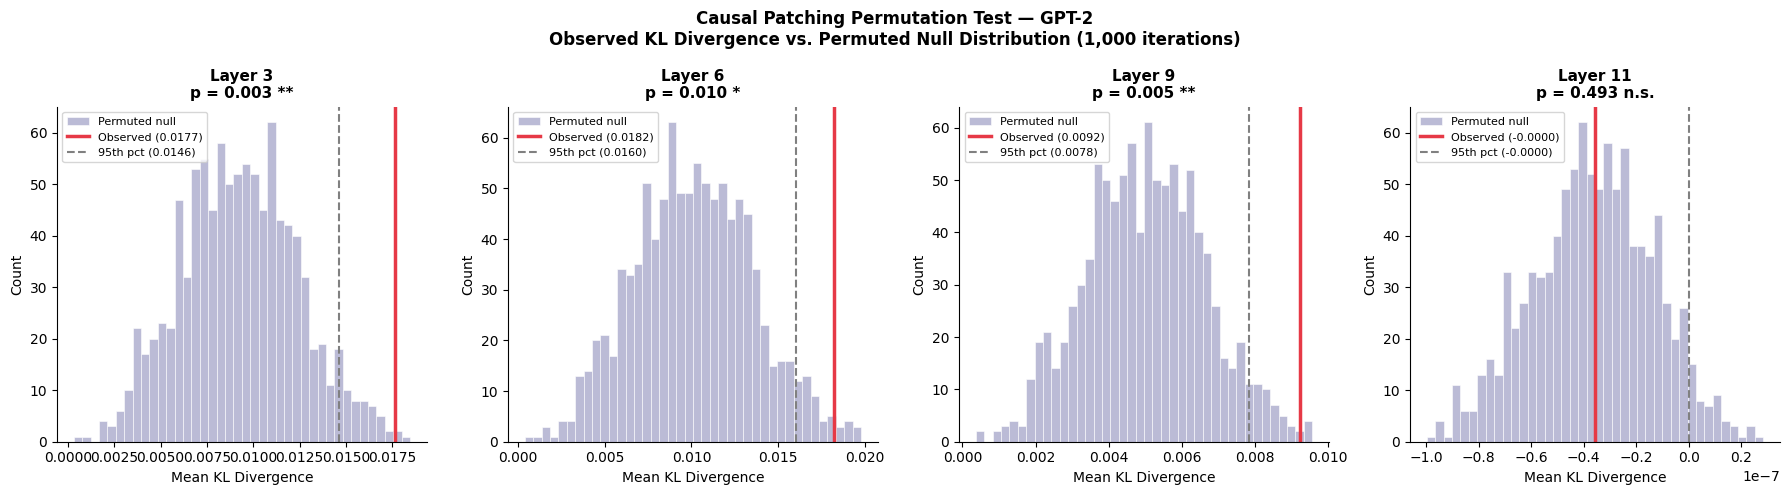


PAPER TEXT:
For use in Table 2 footnote or Section 4.6:
  Layer 3: observed KL = 0.0177, permuted 95th = 0.0146, p = 0.0030 **
  Layer 6: observed KL = 0.0182, permuted 95th = 0.0160, p = 0.0100 *
  Layer 9: observed KL = 0.0092, permuted 95th = 0.0078, p = 0.0050 **
  Layer 11: observed KL = -0.0000, permuted 95th = -0.0000, p = 0.4930 n.s.


In [9]:
# Cell 8 — results and figure
print('=' * 65)
print('PERMUTATION TEST RESULTS — GPT-2 Causal Patching')
print('=' * 65)
print()

results_rows = []
for layer in GPT2_LAYERS:
    obs   = observed[layer]['mean']
    perms = perm_means[layer]
    pct   = np.percentile(perms, 95)
    p_val = np.mean(np.array(perms) >= obs)
    sig   = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
    print(f'Layer {layer}:')
    print(f'  Observed mean KL:     {obs:.4f}')
    print(f'  Permuted 95th pct:    {pct:.4f}')
    print(f'  p-value (one-sided):  {p_val:.4f} {sig}')
    results_rows.append({
        'layer': layer, 'observed_kl': round(obs, 4),
        'perm_95th': round(pct, 4),
        'p_value': round(p_val, 4), 'significance': sig
    })
    print()

df = pd.DataFrame(results_rows)
csv_path = f'{OUTPUT_DIR}/patching_permutation_test_gpt2.csv'
df.to_csv(csv_path, index=False)
print(f'Saved: {csv_path}')

# Figure
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Causal Patching Permutation Test — GPT-2\n'
             'Observed KL Divergence vs. Permuted Null Distribution (1,000 iterations)',
             fontsize=12, fontweight='bold')

for ax, layer in zip(axes, GPT2_LAYERS):
    obs   = observed[layer]['mean']
    perms = perm_means[layer]
    row   = [r for r in results_rows if r['layer'] == layer][0]

    ax.hist(perms, bins=40, color='#AAAACC', alpha=0.8,
            edgecolor='white', linewidth=0.5, label='Permuted null')
    ax.axvline(obs, color='#E63946', linewidth=2.5,
               label=f'Observed ({obs:.4f})')
    ax.axvline(np.percentile(perms, 95), color='gray',
               linewidth=1.5, linestyle='--',
               label=f'95th pct ({np.percentile(perms, 95):.4f})')

    sig = row['significance']
    p   = row['p_value']
    ax.set_title(f'Layer {layer}\np = {p:.3f} {sig}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Mean KL Divergence', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
fig_path = f'{OUTPUT_DIR}/patching_permutation_test_gpt2.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f'Saved: {fig_path}')
plt.show()

print()
print('PAPER TEXT:')
print('For use in Table 2 footnote or Section 4.6:')
for row in results_rows:
    print(f'  Layer {row["layer"]}: observed KL = {row["observed_kl"]:.4f}, '
          f'permuted 95th = {row["perm_95th"]:.4f}, '
          f'p = {row["p_value"]:.4f} {row["significance"]}')